In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("loan_approval_dataset.csv")

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.drop("loan_id", axis =1, inplace =True)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [8]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


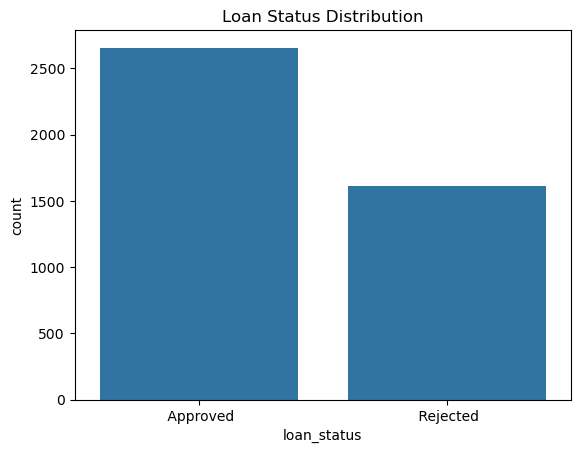

In [12]:

sns.countplot(data=df, x='loan_status')
plt.title("Loan Status Distribution")
plt.show()

In [13]:
df["loan_income_ratio"] = df["loan_amount"] / df["income_annum"]

In [14]:
df["total_assets"] = (
    df["residential_assets_value"]
    + df["commercial_assets_value"]
    + df["luxury_assets_value"]
    + df["bank_asset_value"]
)

In [15]:
df["loan_per_term"] = df["loan_amount"] / df["loan_term"]

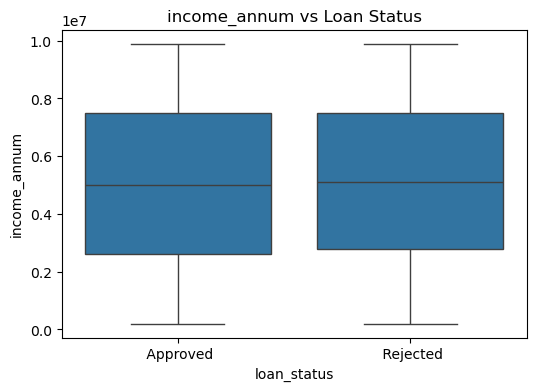

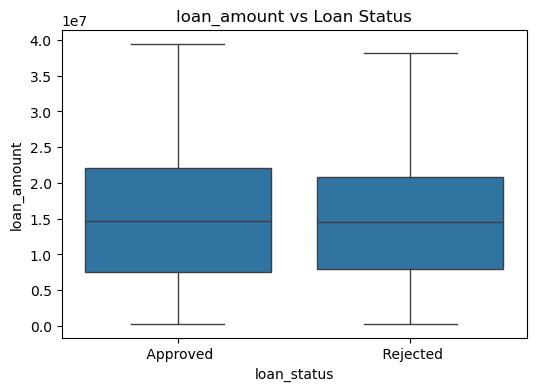

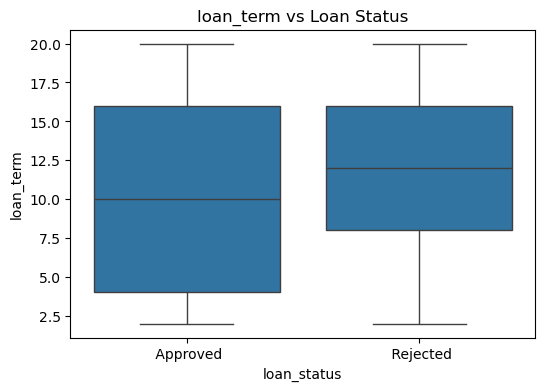

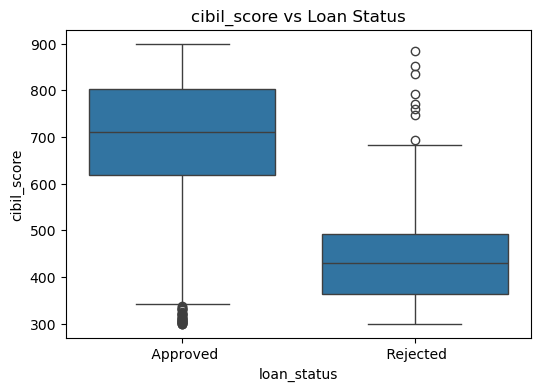

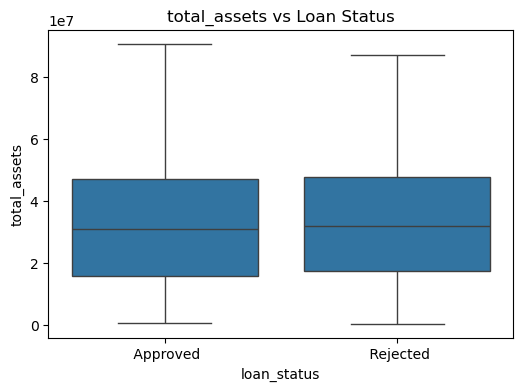

In [16]:
num_cols = [
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'total_assets'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.title(f'{col} vs Loan Status')
    plt.show()

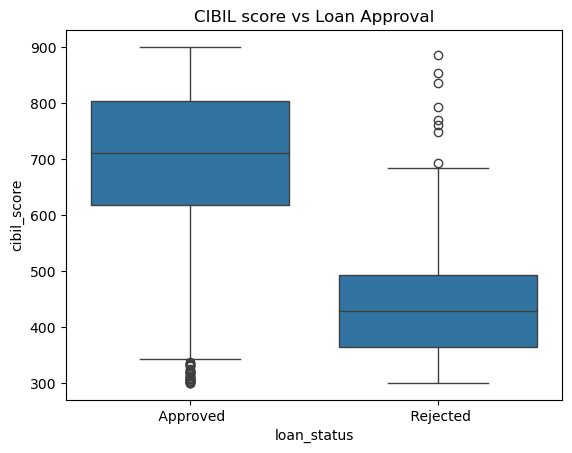

In [18]:
sns.boxplot(data=df, x='loan_status',y='cibil_score')

plt.title("CIBIL score vs Loan Approval")
plt.show()

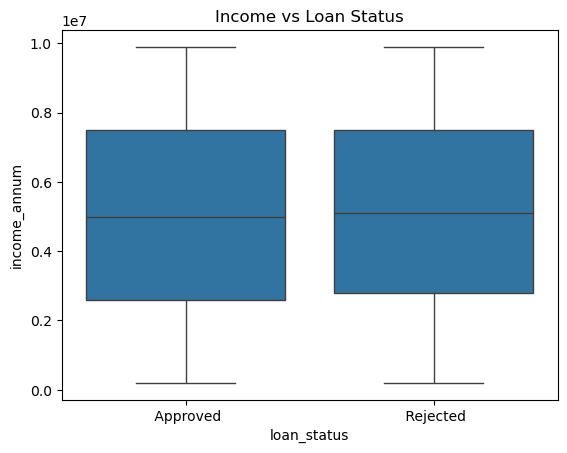

In [21]:
sns.boxplot(
    data=df,
    x='loan_status',
    y='income_annum'
)

plt.title("Income vs Loan Status")
plt.show()

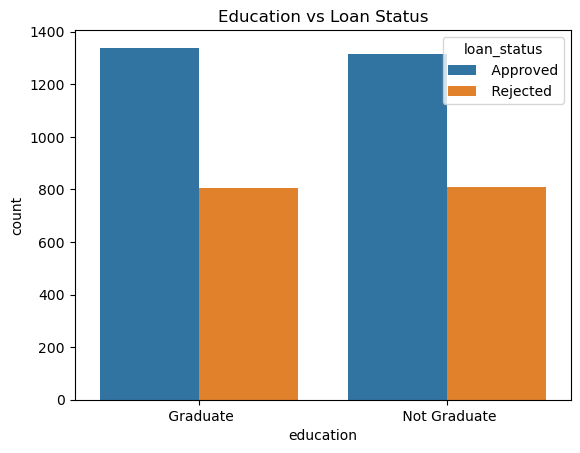

In [22]:
sns.countplot(data=df,x='education', hue='loan_status')

plt.title("Education vs Loan Status")
plt.show()

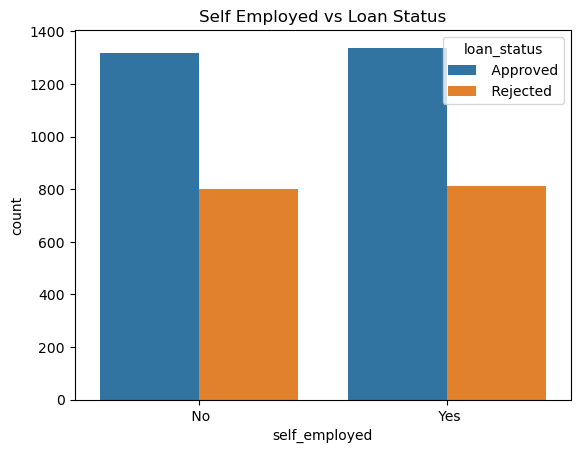

In [23]:
sns.countplot(
    data=df,
    x='self_employed',
    hue='loan_status'
)

plt.title("Self Employed vs Loan Status")
plt.show()

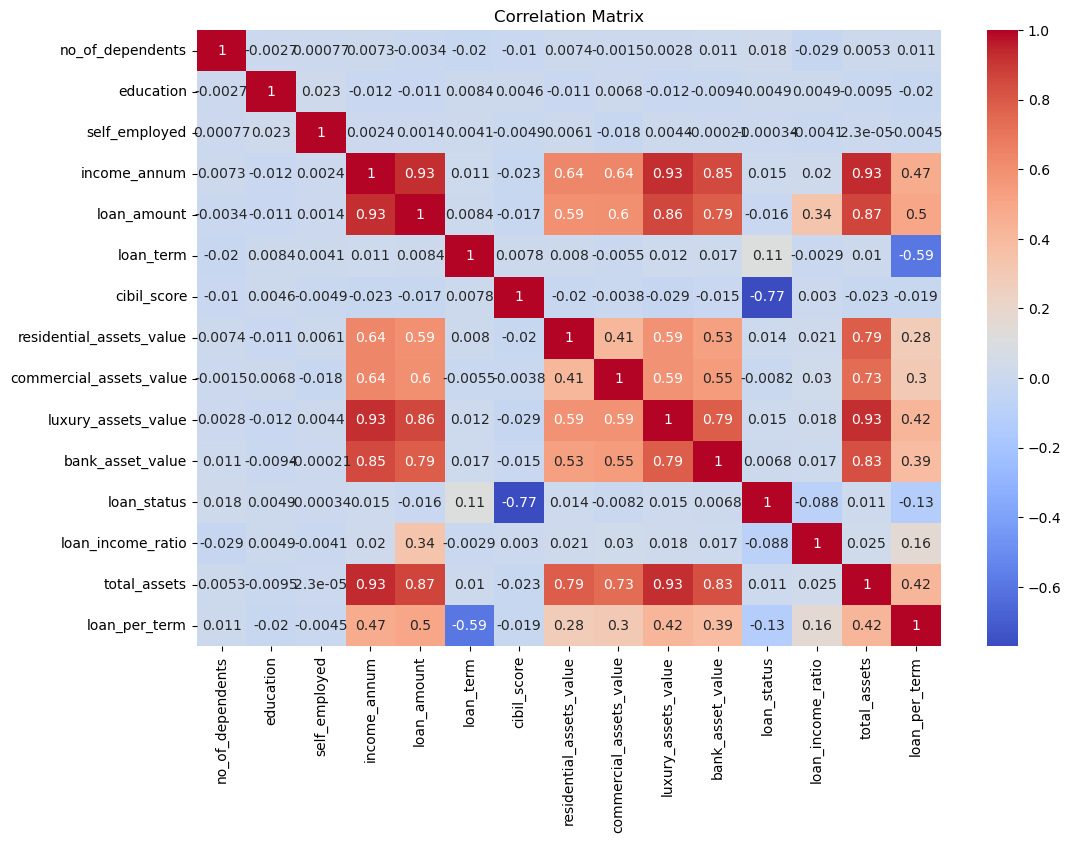

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop(["loan_status"], axis=1)
y = df["loan_status"]


In [29]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [40]:
rf = RandomForestClassifier(n_estimators=500,max_depth=15,random_state=42)
rf.fit(X_train,y_train)


RandomForestClassifier(max_depth=15, n_estimators=500, random_state=42)

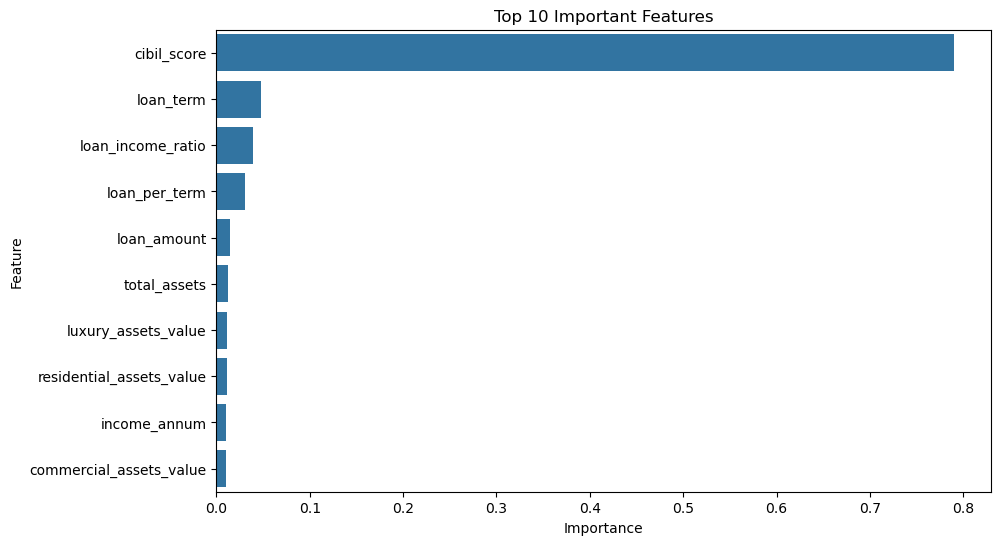

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
y_pred = rf.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)

In [37]:
print("Accuracy :", round(accuracy*100,2), "%")
print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 99.88 %

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       536
           1       1.00      1.00      1.00       318

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



In [38]:
pip install xgboost catboost

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 5.9 MB/s eta 0:00:17
   ---------------------------------------- 1.0/100.2 MB 5.2 MB/s eta 0:00:20
   ---------------------------------------- 1.0/100.2 MB 5.2 MB/s eta 0:00:20
    --------------------------------------- 2.1/100.2 MB 2.8 MB/s eta 0:00:35
    --------------------------------------- 2.1/100.2 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 2.9/100.2 MB 2.5 MB/s eta 0:00:39
   - -------------------------------------- 3.7/100.2 MB 2.6 MB/s eta 0:00:37
   - -------------------------------------- 4.2/100.2 MB 2.8 MB/s eta 0:00:35
   - -------------------------------------- 5.0/100.2 MB 2.7 MB/s eta 0:00:36
   -- ------------------------------------- 5.2/100.2 MB 2.8 MB/s eta 0:00:35
   -- ------------------------------------- 5.5/100.2 MB 2.5 MB/s eta 0:00:39
   -- ------------------------------------- 6.3/100.2 MB 2.6 MB/s eta 0

In [42]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(verbose=0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9929742388758782


In [45]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9995658499953065


In [ ]:
import pickle

pickle.dump(
    model,
    open("loan_approval_model.pkl", "rb")
)
